# Sector-Based Stationarity Analysis — iRacing Telemetry
## ADF & KPSS Tests per Track Sector × Driver × Stint

**Pipeline:**
1. Import shared `config` and `telemetry` modules
2. Load `.ibt` files — multi-file stints are **concatenated automatically**
3. Assign each telemetry sample to a track sector using `LapDistPct`
4. Compute per-lap sector statistics: Mean / Std of TotalG, Speed, Throttle, Brake, Steering
5. Run ADF + KPSS on each `(driver, track, stint, sector, variable)` discrete time series
6. Visualise and export results


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*kpss.*')

# ── project root on path (adjust if notebook is in a sub-folder) ─────────────
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files, load_and_prepare_stint, IRSDK_AVAILABLE

print(f'irsdk available  : {IRSDK_AVAILABLE}')
print(f'Tracks in config : {list(TRACK_CONFIGS.keys())}')
print(f'Driver aliases   : {DRIVER_ALIAS}')

irsdk available  : True
Tracks in config : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C'}


## 1. User Selection

In [2]:
TRACK       = 'summit_point'   # 'charlotte_roval_2025' | 'summit_point'
DRIVER_REF  = 'Rodrigo'
STINT_REF   = 'stint_1'

DRIVER_TEST = 'Tomaz'
STINT_TEST  = 'stint_2'

driver_a = DRIVER_ALIAS.get(DRIVER_REF,  DRIVER_REF)
driver_b = DRIVER_ALIAS.get(DRIVER_TEST, DRIVER_TEST)
print(f'Reference : {driver_a} ({DRIVER_REF}) — {STINT_REF}')
print(f'Test      : {driver_b} ({DRIVER_TEST}) — {STINT_TEST}')

Reference : Driver A (Rodrigo) — stint_1
Test      : Driver B (Tomaz) — stint_2


In [3]:
# ── output directory ────────────────────────────────────────────────────
PROJECT_ROOT  = Path.home() / 'OneDrive/Documents/GitHub/Doutorado/Racing4all'
BASE_IMG_DIR  = PROJECT_ROOT / 'Iracing' / 'img'
COMPARISON_ID = f'{TRACK}_{driver_a}_vs_{driver_b}'
SAVE_DIR      = BASE_IMG_DIR / 'stationarity_analysis'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DPI    = 300
FORMAT = 'png'
print(f'SAVE_DIR → {SAVE_DIR.resolve()}')


SAVE_DIR → C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\stationarity_analysis


## 2. Load All Sessions

In [4]:
all_dfs = {}

for track_id, config in DATASETS.items():
    max_lap_time = config.get('max_lap_time_s', 120.0)
    edges        = TRACK_CONFIGS[track_id]['custom_edges']

    print(f"\n{'='*65}")
    print(f"Track : {track_id}  |  Car: {config['car']}  |  Max lap: {max_lap_time}s")
    print(f"{'='*65}")

    for driver, stints in config['sessions'].items():
        alias = DRIVER_ALIAS.get(driver, driver)

        for stint_name in stints:
            paths   = resolve_stint_files(track_id, driver, stint_name)
            key     = (track_id, alias, stint_name)
            missing = [p for p in paths if not p.exists()]
            if missing:
                for m in missing:
                    print(f'  WARNING  Not found: {m.name}')
                if len(missing) == len(paths):
                    continue

            print(f'  {alias} | {stint_name}  ({len(paths)} file(s))')
            df_valid, _ = load_and_prepare_stint(
                paths=paths, edges=edges,
                max_lap_time_s=max_lap_time, verbose=True)

            if df_valid.empty:
                print('  -> ERROR: no valid laps')
                continue

            n_valid = df_valid['Lap'].nunique()
            print(f'  -> OK  {n_valid} valid laps  |  {df_valid["Sector"].nunique()} sectors')
            all_dfs[key] = df_valid

print(f'\nTotal sessions loaded: {len(all_dfs)}')


Track : charlotte_roval_2025  |  Car: Mazda MX-5  |  Max lap: 120.0s
  Driver B | stint_1  (1 file(s))
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
  -> OK  25 valid laps  |  18 sectors
  Driver B | stint_2  (2 file(s))
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-0

## 3. Build Sector-Level Lap Series

In [5]:
SECTOR_VARS = {
    'Mean_TotalG':             'Mean Total G-Force (G)',
    'Std_TotalG':              'Std Dev Total G-Force (G)',
    'Mean_Speed_KPH':          'Mean Speed (km/h)',
    'Mean_Throttle_Pct':       'Mean Throttle (%)',
    'Mean_Brake_Pct':          'Mean Brake (%)',
    'Mean_SteeringWheelAngle': 'Mean Steering Angle (rad)',
    'Std_SteeringWheelAngle':  'Std Dev Steering Angle (rad)',
}

sector_rows = []
for (track_id, alias, stint_name), df in all_dfs.items():
    sector_names = TRACK_CONFIGS[track_id]['sector_names']
    for (lap, sector), grp in df.groupby(['Lap', 'Sector']):
        if pd.isna(sector):
            continue
        sector_id    = int(sector)
        sector_label = sector_names.get(sector_id, f'S{sector_id:02d}')
        sector_rows.append({
            'Track': track_id, 'Driver': alias, 'Stint': stint_name,
            'Lap': int(lap), 'Sector': sector_id, 'Sector_Name': sector_label,
            'Session': f'{alias} | {track_id} | {stint_name}',
            'Mean_TotalG':             grp['TotalAccel_G'].mean(),
            'Std_TotalG':              grp['TotalAccel_G'].std(),
            'Mean_Speed_KPH':          grp['Speed_KPH'].mean(),
            'Mean_Throttle_Pct':       grp['Throttle_Pct'].mean(),
            'Mean_Brake_Pct':          grp['Brake_Pct'].mean(),
            'Mean_SteeringWheelAngle': grp['SteeringWheelAngle'].mean(),
            'Std_SteeringWheelAngle':  grp['SteeringWheelAngle'].std(),
        })

df_sectors = pd.DataFrame(sector_rows).reset_index(drop=True)
print(f'Shape    : {df_sectors.shape}')
print(f'Drivers  : {df_sectors["Driver"].unique().tolist()}')
print(f'Sessions : {df_sectors["Session"].nunique()}')
df_sectors.head()

Shape    : (2720, 14)
Drivers  : ['Driver B', 'Driver C', 'Driver A']
Sessions : 9


,Track,Driver,Stint,Lap,Sector,Sector_Name,Session,Mean_TotalG,Std_TotalG,Mean_Speed_KPH,Mean_Throttle_Pct,Mean_Brake_Pct,Mean_SteeringWheelAngle,Std_SteeringWheelAngle
0,charlotte_roval_2025,Driver B,stint_1,1,1,T1 (Heartlands),Driver B | charlotte_roval_2025 | stint_1,0.485986,0.333299,132.784474,76.863996,8.137634,0.065743,0.098421
1,charlotte_roval_2025,Driver B,stint_1,1,2,T2,Driver B | charlotte_roval_2025 | stint_1,0.908498,0.417430,116.961652,73.880105,2.361101,0.379804,0.259655
2,charlotte_roval_2025,Driver B,stint_1,1,3,T3 (Infield),Driver B | charlotte_roval_2025 | stint_1,1.030420,0.428778,142.217175,75.218984,4.647434,0.346705,0.393370
3,charlotte_roval_2025,Driver B,stint_1,1,4,T4,Driver B | charlotte_roval_2025 | stint_1,1.225454,0.338266,123.333976,28.406974,4.769187,-0.278111,0.206579
4,charlotte_roval_2025,Driver B,stint_1,1,5,T5/T6 Transition,Driver B | charlotte_roval_2025 | stint_1,0.619067,0.466362,128.965223,95.113267,0.000000,-0.191296,0.279310


## 4. Exploratory Plots — Sector Profiles (Mean ± 1σ)

  saved: sector_profile_Mean_TotalG_summit_point.png


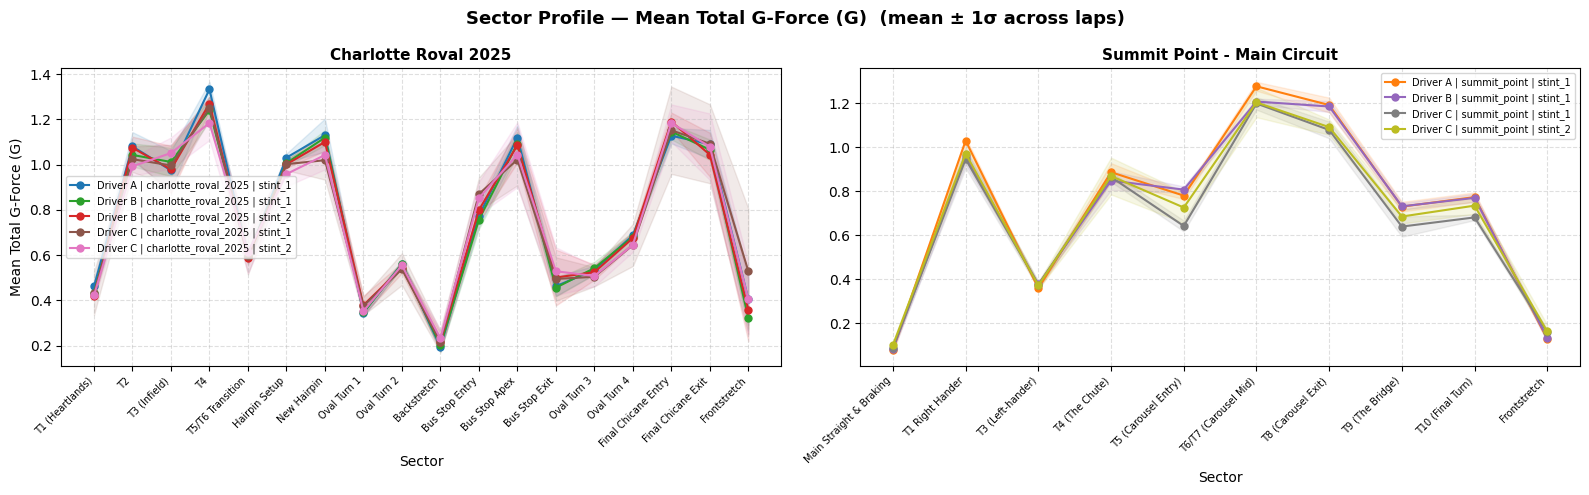

  saved: sector_profile_Std_TotalG_summit_point.png


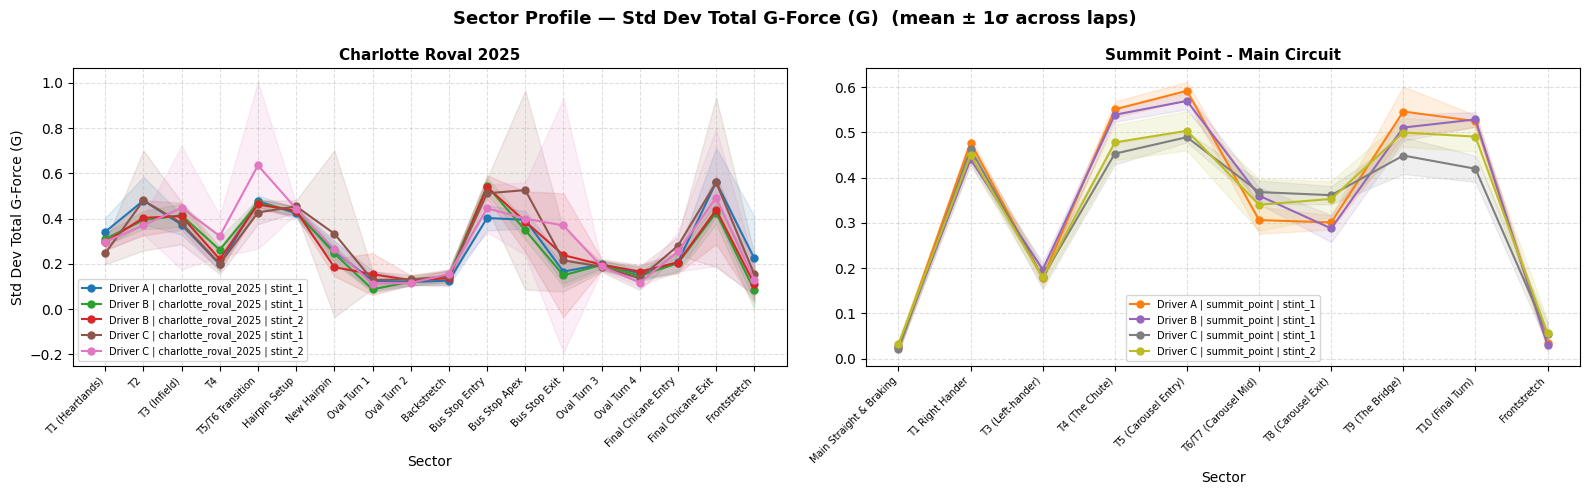

  saved: sector_profile_Mean_Speed_KPH_summit_point.png


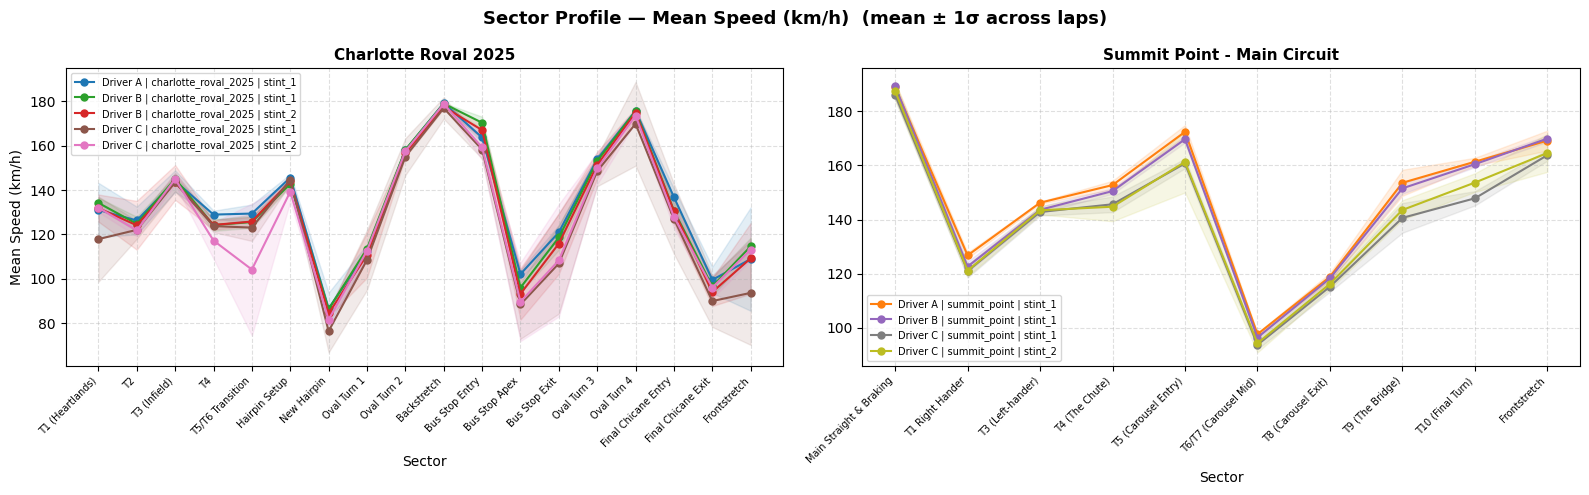

  saved: sector_profile_Mean_Throttle_Pct_summit_point.png


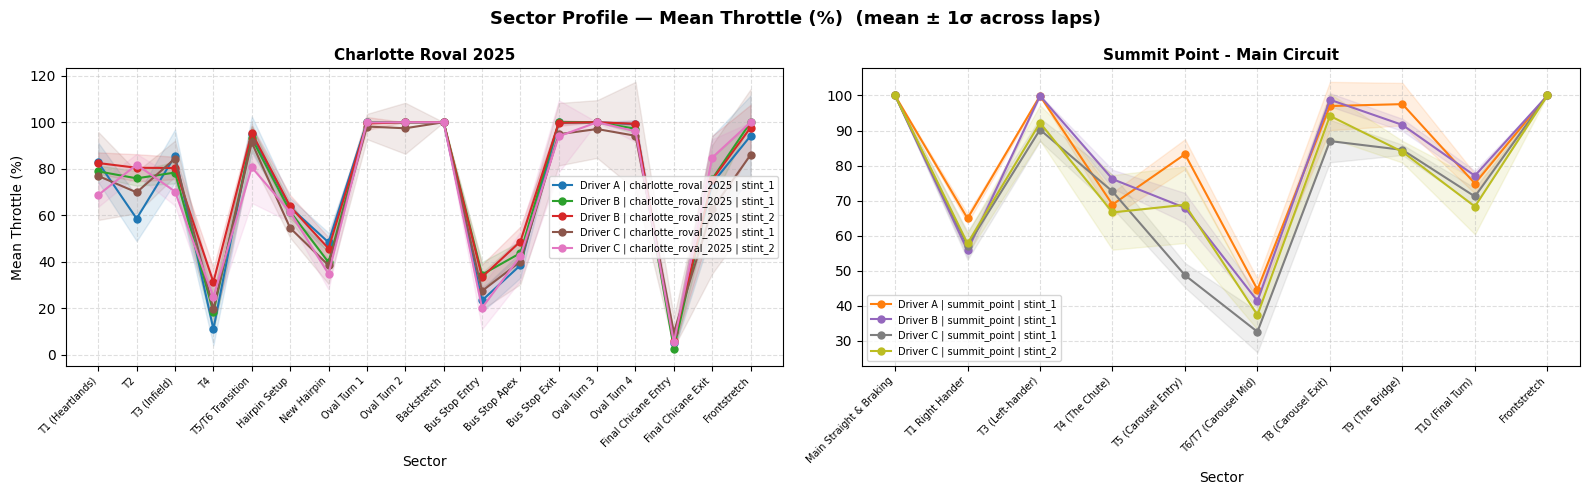

  saved: sector_profile_Mean_Brake_Pct_summit_point.png


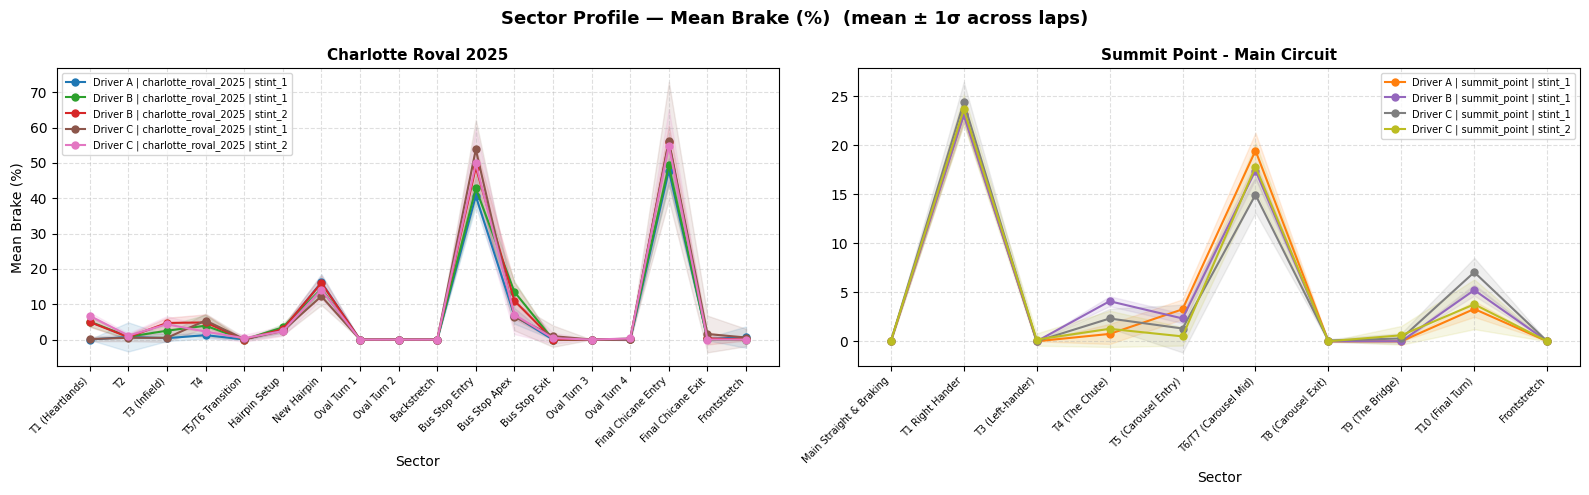

  saved: sector_profile_Mean_SteeringWheelAngle_summit_point.png


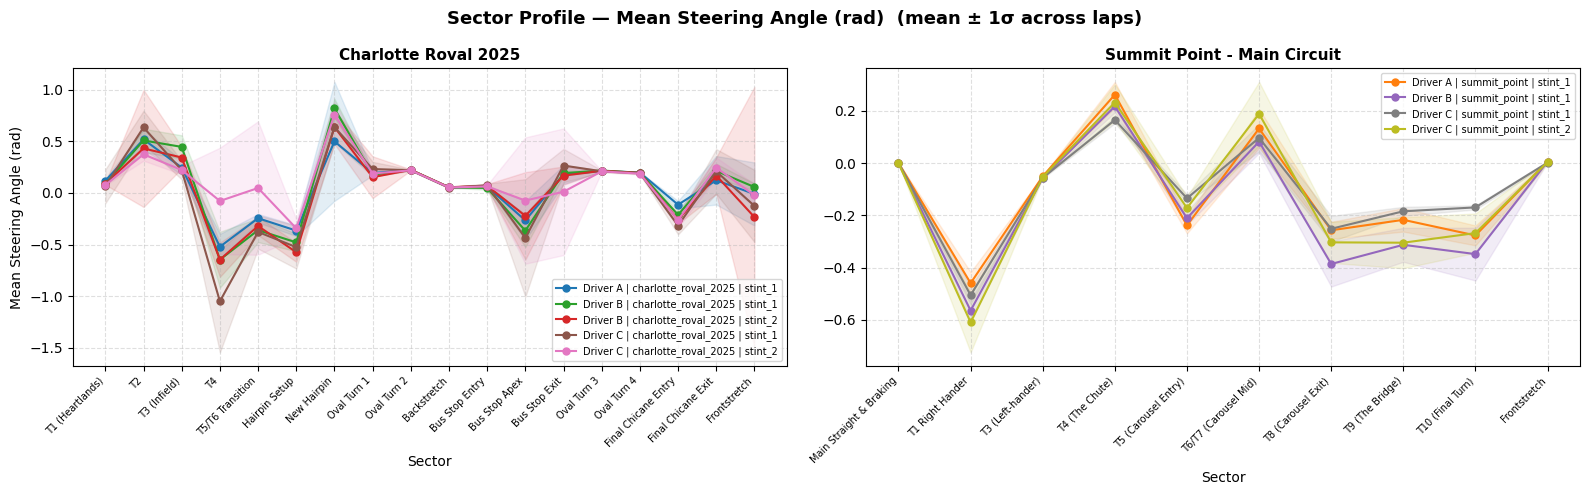

  saved: sector_profile_Std_SteeringWheelAngle_summit_point.png


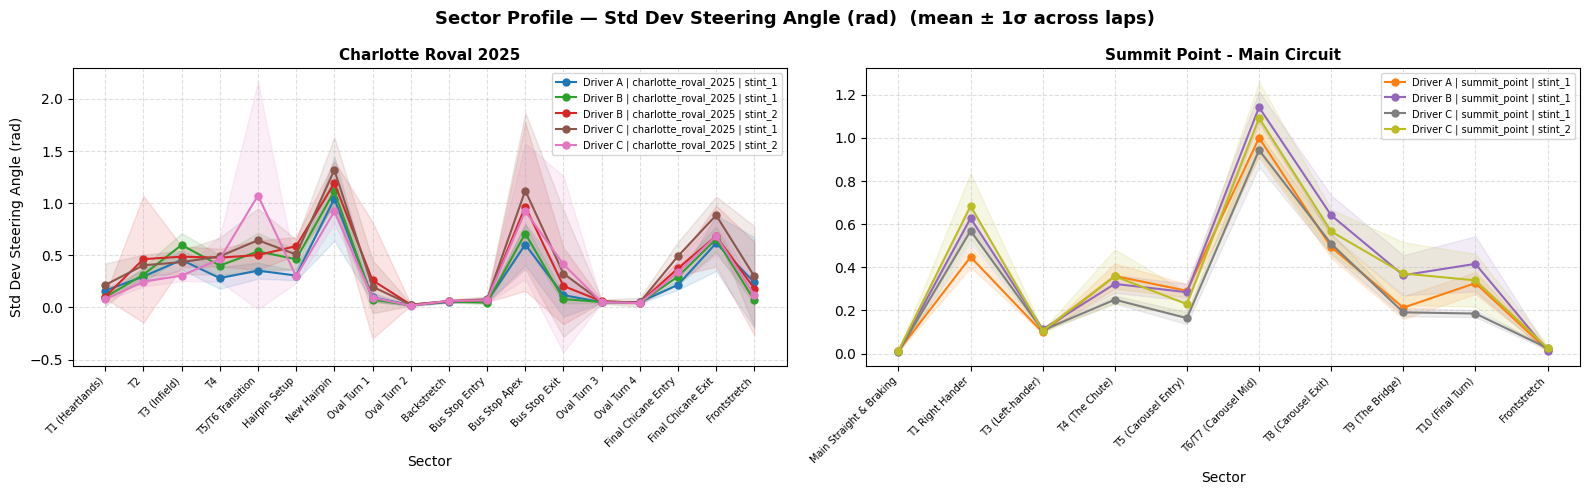

In [6]:
tracks       = sorted(df_sectors['Track'].unique())
sessions_all = sorted(df_sectors['Session'].unique())
palette      = sns.color_palette('tab10', n_colors=len(sessions_all))
cmap_ses     = dict(zip(sessions_all, palette))

for var, label in SECTOR_VARS.items():
    fig, axes = plt.subplots(1, len(tracks), figsize=(8*len(tracks), 5), sharey=False)
    if len(tracks) == 1: axes = [axes]
    for ax, track_id in zip(axes, tracks):
        cfg          = TRACK_CONFIGS[track_id]
        sector_names = cfg['sector_names']
        n_sectors    = len(sector_names)
        for sess in sorted(df_sectors[df_sectors['Track']==track_id]['Session'].unique()):
            sub = (df_sectors[(df_sectors['Session']==sess)&(df_sectors['Track']==track_id)]
                   .groupby('Sector')[var].agg(['mean','std'])
                   .reindex(range(1, n_sectors+1)))
            ax.plot(sub.index, sub['mean'], marker='o', markersize=5,
                    linewidth=1.5, label=sess, color=cmap_ses[sess])
            ax.fill_between(sub.index, sub['mean']-sub['std'],
                            sub['mean']+sub['std'], color=cmap_ses[sess], alpha=0.12)
        ax.set_xticks(range(1, n_sectors+1))
        ax.set_xticklabels([sector_names[i] for i in range(1,n_sectors+1)],
                           rotation=45, ha='right', fontsize=7)
        ax.set_title(cfg['track_name'], fontsize=11, fontweight='bold')
        ax.set_xlabel('Sector'); ax.set_ylabel(label if ax==axes[0] else '')
        ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
    fig.suptitle(f'Sector Profile — {label}  (mean ± 1σ across laps)',
                 fontsize=13, fontweight='bold')
    _fname = f'sector_profile_{var}_{track_id}.{FORMAT}'
    fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
    print(f'  saved: {_fname}')
    plt.tight_layout(); plt.show()

## 5. ADF & KPSS Functions

In [7]:
def run_adf(series, regression='ct'):
    s = series.dropna()
    if len(s) < 8 or s.max() == s.min():
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_1pct=np.nan, stationary=None)
    try:
        res = adfuller(s, autolag='AIC', regression=regression)
        return dict(stat=round(res[0],4), p=round(res[1],6), lags=res[2],
                    crit_1pct=round(res[4]['1%'],4), stationary=bool(res[1]<0.05))
    except: return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_1pct=np.nan, stationary=None)

def run_kpss(series, regression='ct'):
    s = series.dropna()
    if len(s) < 8 or s.max() == s.min():
        return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_5pct=np.nan, stationary=None)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            stat, p, lags, crit = kpss(s, regression=regression, nlags='auto')
        return dict(stat=round(stat,4), p=round(p,6), lags=lags,
                    crit_5pct=round(crit['5%'],4), stationary=bool(p>=0.05))
    except: return dict(stat=np.nan, p=np.nan, lags=np.nan, crit_5pct=np.nan, stationary=None)

def verdict(adf_s, kpss_s):
    if adf_s is None or kpss_s is None: return 'N/A'
    if     adf_s and     kpss_s: return 'Stationary'
    if not adf_s and not kpss_s: return 'Non-Stationary'
    if     adf_s and not kpss_s: return 'Difference-Stationary'
    return 'Trend-Stationary'

print('ADF & KPSS functions defined.')

ADF & KPSS functions defined.


## 6. Run Tests

In [8]:
REGRESSION   = 'ct'
test_results = []

for (track_id, driver, stint, sector_id, sector_name), grp in \
        df_sectors.groupby(['Track','Driver','Stint','Sector','Sector_Name']):
    grp_sorted = grp.sort_values('Lap')
    for var, label in SECTOR_VARS.items():
        series = grp_sorted[var].reset_index(drop=True)
        adf_r  = run_adf(series,  regression=REGRESSION)
        kpss_r = run_kpss(series, regression=REGRESSION)
        test_results.append({
            'Track': track_id, 'Driver': driver, 'Stint': stint,
            'Sector': sector_id, 'Sector_Name': sector_name,
            'Variable': var, 'Label': label,
            'N_Laps': int(series.notna().sum()),
            'ADF_Statistic': adf_r['stat'], 'ADF_p_value': adf_r['p'],
            'ADF_Lags': adf_r['lags'], 'ADF_Crit_1pct': adf_r['crit_1pct'],
            'ADF_Stationary': adf_r['stationary'],
            'KPSS_Statistic': kpss_r['stat'], 'KPSS_p_value': kpss_r['p'],
            'KPSS_Lags': kpss_r['lags'], 'KPSS_Crit_5pct': kpss_r['crit_5pct'],
            'KPSS_Stationary': kpss_r['stationary'],
            'Verdict': verdict(adf_r['stationary'], kpss_r['stationary']),
        })

df_results = pd.DataFrame(test_results)
print(f'{len(df_results)} tests completed')
df_results.head()

c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2


910 tests completed


,Track,Driver,Stint,Sector,Sector_Name,Variable,Label,N_Laps,ADF_Statistic,ADF_p_value,ADF_Lags,ADF_Crit_1pct,ADF_Stationary,KPSS_Statistic,KPSS_p_value,KPSS_Lags,KPSS_Crit_5pct,KPSS_Stationary,Verdict
0,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_TotalG,Mean Total G-Force (G),36,-5.6266,0.000013,0.0,-4.2438,True,0.0760,0.100000,2.0,0.146,True,Stationary
1,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Std_TotalG,Std Dev Total G-Force (G),36,-4.0259,0.008075,1.0,-4.2530,True,0.0929,0.100000,0.0,0.146,True,Stationary
2,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Speed_KPH,Mean Speed (km/h),36,-4.1196,0.005901,0.0,-4.2438,True,0.0789,0.100000,1.0,0.146,True,Stationary
3,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Throttle_Pct,Mean Throttle (%),36,-5.9803,0.000002,0.0,-4.2438,True,0.1339,0.072316,0.0,0.146,True,Stationary
4,charlotte_roval_2025,Driver A,stint_1,1,T1 (Heartlands),Mean_Brake_Pct,Mean Brake (%),36,-5.9507,0.000003,0.0,-4.2438,True,0.0837,0.100000,2.0,0.146,True,Stationary


## 7. Verdict Heatmap

In [10]:
'''
VERDICT_COLORS = {
    'Stationary': '#2ecc71', 'Non-Stationary': '#e74c3c',
    'Difference-Stationary': '#f39c12', 'Trend-Stationary': '#3498db', 'N/A': '#bdc3c7',
}
VERDICT_SHORT  = {'Stationary':'S','Non-Stationary':'NS',
                  'Difference-Stationary':'DS','Trend-Stationary':'TS','N/A':'—'}
verdict_order  = list(VERDICT_COLORS.keys())
cmap_v         = ListedColormap(list(VERDICT_COLORS.values()))
bounds_v       = np.arange(-0.5, len(VERDICT_COLORS)+0.5, 1)
norm_v         = BoundaryNorm(bounds_v, cmap_v.N)

for track_id in sorted(df_results['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    track_res    = df_results[df_results['Track']==track_id]
    sectors      = sorted(track_res['Sector'].unique())
    sec_labels   = [sector_names.get(s,f'S{s}') for s in sectors]

    for var, label in SECTOR_VARS.items():
        var_res        = track_res[track_res['Variable']==var]
        sessions_local = sorted(var_res[['Driver','Stint']].drop_duplicates()
            .apply(lambda r: f"{r['Driver']} | {r['Stint']}", axis=1).unique())

        matrix_v = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)
        for _, row in var_res.iterrows():
            matrix_v.at[f"{row['Driver']} | {row['Stint']}", row['Sector']] = row['Verdict']

        matrix_n = matrix_v.applymap(
            lambda v: verdict_order.index(v) if v in verdict_order else len(verdict_order))

        fig, ax = plt.subplots(
            figsize=(max(10,len(sectors)*0.9), max(3,len(sessions_local)*0.7+1.5)))
        ax.imshow(matrix_n.values.astype(float), cmap=cmap_v, norm=norm_v, aspect='auto')
        for i in range(matrix_v.shape[0]):
            for j in range(matrix_v.shape[1]):
                val = matrix_v.iloc[i,j]
                if pd.notna(val) and val != 'nan':
                    ax.text(j, i, VERDICT_SHORT.get(val,val),
                            ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        ax.set_xticks(range(len(sectors)))
        ax.set_xticklabels(sec_labels, rotation=45, ha='right', fontsize=7)
        ax.set_yticks(range(len(sessions_local)))
        ax.set_yticklabels(sessions_local, fontsize=8)
        ax.legend(handles=[Patch(facecolor=c,label=f'{k} ({VERDICT_SHORT[k]})')
                            for k,c in VERDICT_COLORS.items()],
                  loc='upper right', bbox_to_anchor=(1.0,-0.25), ncol=3, fontsize=7)
        ax.set_title(f"Stationarity Verdict — {cfg['track_name']}\n{label}",
                     fontsize=12, fontweight='bold')
        _fname = f'verdict_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nVERDICT_COLORS = {\n    \'Stationary\': \'#2ecc71\', \'Non-Stationary\': \'#e74c3c\',\n    \'Difference-Stationary\': \'#f39c12\', \'Trend-Stationary\': \'#3498db\', \'N/A\': \'#bdc3c7\',\n}\nVERDICT_SHORT  = {\'Stationary\':\'S\',\'Non-Stationary\':\'NS\',\n                  \'Difference-Stationary\':\'DS\',\'Trend-Stationary\':\'TS\',\'N/A\':\'—\'}\nverdict_order  = list(VERDICT_COLORS.keys())\ncmap_v         = ListedColormap(list(VERDICT_COLORS.values()))\nbounds_v       = np.arange(-0.5, len(VERDICT_COLORS)+0.5, 1)\nnorm_v         = BoundaryNorm(bounds_v, cmap_v.N)\n\nfor track_id in sorted(df_results[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    track_res    = df_results[df_results[\'Track\']==track_id]\n    sectors      = sorted(track_res[\'Sector\'].unique())\n    sec_labels   = [sector_names.get(s,f\'S{s}\') for s in sectors]\n\n    for var, label in SECTOR_VARS.items():\n        var_res        = track_res[tr

## 8. ADF p-value Heatmap

In [11]:
'''
for track_id in sorted(df_results['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    track_res    = df_results[df_results['Track']==track_id]
    sectors      = sorted(track_res['Sector'].unique())
    sec_labels   = [f"S{s}\n{sector_names.get(s,'')}" for s in sectors]

    for var, label in SECTOR_VARS.items():
        var_res        = track_res[track_res['Variable']==var]
        sessions_local = sorted(var_res[['Driver','Stint']].drop_duplicates()
            .apply(lambda r: f"{r['Driver']} | {r['Stint']}", axis=1).unique())

        matrix_p     = pd.DataFrame(index=sessions_local, columns=sectors, dtype=float)
        matrix_annot = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)
        for _, row in var_res.iterrows():
            key = f"{row['Driver']} | {row['Stint']}"
            p   = row['ADF_p_value']
            matrix_p.at[key, row['Sector']] = p
            matrix_annot.at[key, row['Sector']] = (
                'N/A' if pd.isna(p) else '<1e-10' if p==0.0
                else f'{p:.2e}' if p<0.001 else f'{p:.3f}')

        fig, ax = plt.subplots(
            figsize=(max(12,len(sectors)*1.1), max(3,len(sessions_local)*1.0+1.5)))
        sns.heatmap(matrix_p.astype(float), ax=ax, cmap='RdYlGn_r', vmin=0, vmax=0.10,
                    annot=matrix_annot, fmt='', linewidths=0.8, linecolor='white',
                    cbar_kws={'label':'ADF p-value','shrink':0.6}, xticklabels=sec_labels)
        for i,sess in enumerate(sessions_local):
            for j,sec in enumerate(sectors):
                p_val = matrix_p.at[sess,sec]
                if pd.notna(p_val) and p_val<0.05:
                    ax.add_patch(plt.Rectangle((j,i),1,1,fill=False,
                                               edgecolor='black',linewidth=2.0,clip_on=False))
        ax.tick_params(axis='x',rotation=45,labelsize=8)
        ax.tick_params(axis='y',rotation=0,labelsize=9)
        ax.set_xlabel('Sector',fontsize=10,labelpad=10)
        ax.set_ylabel('Session',fontsize=10)
        ax.set_title(
            f"ADF p-value per Sector — {cfg['track_name']}\n{label}\n"
            '(green = stationary p<0.05  |  black border = significant)',
            fontsize=12, fontweight='bold', pad=12)
        _fname = f'adf_pvalue_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nfor track_id in sorted(df_results[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    track_res    = df_results[df_results[\'Track\']==track_id]\n    sectors      = sorted(track_res[\'Sector\'].unique())\n    sec_labels   = [f"S{s}\n{sector_names.get(s,\'\')}" for s in sectors]\n\n    for var, label in SECTOR_VARS.items():\n        var_res        = track_res[track_res[\'Variable\']==var]\n        sessions_local = sorted(var_res[[\'Driver\',\'Stint\']].drop_duplicates()\n            .apply(lambda r: f"{r[\'Driver\']} | {r[\'Stint\']}", axis=1).unique())\n\n        matrix_p     = pd.DataFrame(index=sessions_local, columns=sectors, dtype=float)\n        matrix_annot = pd.DataFrame(index=sessions_local, columns=sectors, dtype=str)\n        for _, row in var_res.iterrows():\n            key = f"{row[\'Driver\']} | {row[\'Stint\']}"\n            p   = row[\'ADF_p_value\']\n            matrix_p.at[key, row[\'Sector\']] = p\n     

## 9. Rolling Statistics per Sector

In [12]:
'''
WINDOW = 5
for track_id in sorted(df_sectors['Track'].unique()):
    cfg          = TRACK_CONFIGS[track_id]
    sector_names = cfg['sector_names']
    sectors      = sorted(df_sectors[df_sectors['Track']==track_id]['Sector'].dropna().unique())
    sessions_t   = sorted(df_sectors[df_sectors['Track']==track_id]['Session'].unique())

    for var, label in SECTOR_VARS.items():
        ncols = 4; nrows = (len(sectors)+ncols-1)//ncols
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(5.5*ncols, 3.5*nrows), sharex=False, sharey=False)
        axes = axes.flatten()
        for idx, sec in enumerate(sectors):
            ax     = axes[idx]
            sec_df = df_sectors[(df_sectors['Track']==track_id)&(df_sectors['Sector']==sec)]
            for sess in sessions_t:
                sub = sec_df[sec_df['Session']==sess].sort_values('Lap')
                if sub.empty: continue
                s    = sub[var].reset_index(drop=True)
                laps = sub['Lap'].values
                rm   = s.rolling(WINDOW,center=True).mean()
                rs   = s.rolling(WINDOW,center=True).std()
                c    = cmap_ses[sess]
                ax.plot(laps,s,color=c,alpha=0.25,linewidth=0.8,marker='o',markersize=2)
                ax.plot(laps,rm,color=c,linewidth=1.8,label=sess.split(' | ')[0])
                ax.fill_between(laps,rm-rs,rm+rs,color=c,alpha=0.12)
            ax.set_title(f"S{int(sec):02d} — {sector_names.get(int(sec),f'S{sec}')}",
                         fontsize=8,fontweight='bold')
            ax.set_xlabel('Lap (n)',fontsize=7)
            ax.set_ylabel(label.split(' (')[0],fontsize=7)
            ax.legend(fontsize=6); ax.grid(True,linestyle='--',alpha=0.4)
        for j in range(len(sectors),len(axes)): axes[j].set_visible(False)
        fig.suptitle(f'Rolling Statistics (w={WINDOW}) — {label}\n{cfg["track_name"]}',
                     fontsize=12,fontweight='bold')
        _fname = f'rolling_{var}_{track_id}.{FORMAT}'
        fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
        print(f'  saved: {_fname}')
        plt.tight_layout(); plt.show()
        '''

'\nWINDOW = 5\nfor track_id in sorted(df_sectors[\'Track\'].unique()):\n    cfg          = TRACK_CONFIGS[track_id]\n    sector_names = cfg[\'sector_names\']\n    sectors      = sorted(df_sectors[df_sectors[\'Track\']==track_id][\'Sector\'].dropna().unique())\n    sessions_t   = sorted(df_sectors[df_sectors[\'Track\']==track_id][\'Session\'].unique())\n\n    for var, label in SECTOR_VARS.items():\n        ncols = 4; nrows = (len(sectors)+ncols-1)//ncols\n        fig, axes = plt.subplots(nrows, ncols,\n                                 figsize=(5.5*ncols, 3.5*nrows), sharex=False, sharey=False)\n        axes = axes.flatten()\n        for idx, sec in enumerate(sectors):\n            ax     = axes[idx]\n            sec_df = df_sectors[(df_sectors[\'Track\']==track_id)&(df_sectors[\'Sector\']==sec)]\n            for sess in sessions_t:\n                sub = sec_df[sec_df[\'Session\']==sess].sort_values(\'Lap\')\n                if sub.empty: continue\n                s    = sub[var].reset_i

## 10. Summary — Stationarity Rate per Driver × Track

  saved: stationarity_distribution_alltracks.png


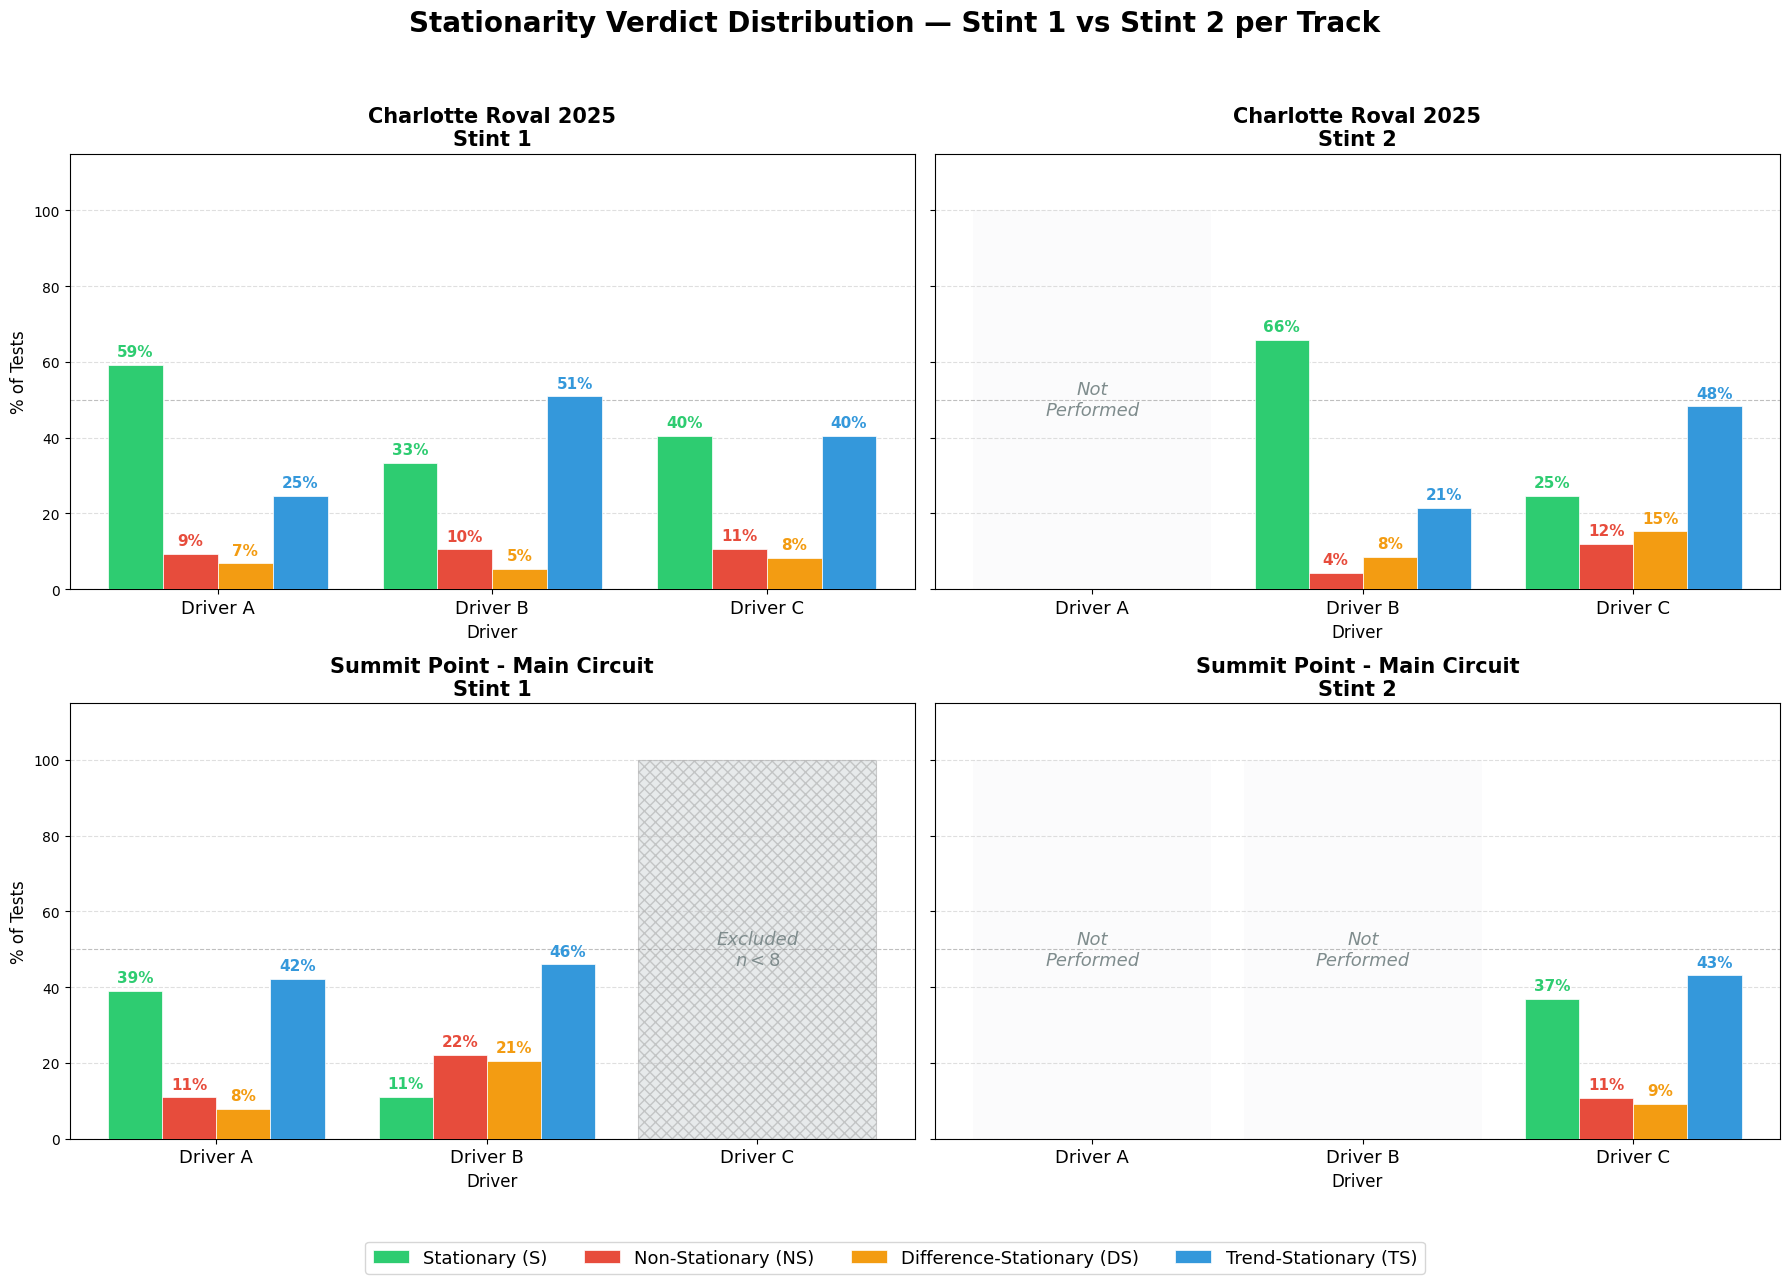

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 10. Summary — Stationarity Rate per Driver × Track × Stint (2×2 grid)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VERDICT_COLS = ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']
VERDICT_COLORS_BAR = {
    'Stationary_%':       '#2ecc71',
    'Non-Stationary_%':   '#e74c3c',
    'Diff-Stationary_%':  '#f39c12',
    'Trend-Stationary_%': '#3498db',
}
VERDICT_LABELS_BAR = {
    'Stationary_%':       'Stationary (S)',
    'Non-Stationary_%':   'Non-Stationary (NS)',
    'Diff-Stationary_%':  'Difference-Stationary (DS)',
    'Trend-Stationary_%': 'Trend-Stationary (TS)',
}

# ── build per-stint summary ────────────────────────────────────────────────
if 'df_summary_stint' not in dir() or True:
    summary_stint_rows = []
    for (track_id, driver, stint), grp in df_results.groupby(['Track', 'Driver', 'Stint']):
        valid = grp[grp['Verdict'] != 'N/A']
        if valid.empty:
            continue
        v = len(valid)
        summary_stint_rows.append({
            'Track': track_id, 'Driver': driver, 'Stint': stint,
            'Stationary_%':       round(100*(valid['Verdict']=='Stationary').sum()/v, 1),
            'Non-Stationary_%':   round(100*(valid['Verdict']=='Non-Stationary').sum()/v, 1),
            'Diff-Stationary_%':  round(100*(valid['Verdict']=='Difference-Stationary').sum()/v, 1),
            'Trend-Stationary_%': round(100*(valid['Verdict']=='Trend-Stationary').sum()/v, 1),
        })
    df_summary_stint = pd.DataFrame(summary_stint_rows).sort_values(['Track','Driver','Stint'])

# ── layout: rows = tracks, cols = stints ─────────────────────────────────────
tracks      = sorted(df_summary_stint['Track'].unique())
all_stints  = sorted(df_summary_stint['Stint'].unique())   # ['stint_1', 'stint_2']
n_rows, n_cols = len(tracks), len(all_stints)

# 1. FIGSIZE AMPLIADO para acomodar fontes maiores sem sobreposição
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(9 * n_cols, 6.5 * n_rows),
    sharey=True,
)
if n_rows == 1: axes = axes[np.newaxis, :]
if n_cols == 1: axes = axes[:, np.newaxis]

bar_w   = 0.20 # Barras mais largas
n_verd  = len(VERDICT_COLS)
offsets = np.linspace(-(n_verd-1)/2, (n_verd-1)/2, n_verd) * bar_w

legend_handles = [
    plt.Rectangle((0,0), 1, 1,
                  facecolor=VERDICT_COLORS_BAR[col],
                  edgecolor='white', linewidth=0.5,
                  label=VERDICT_LABELS_BAR[col])
    for col in VERDICT_COLS
]

for r, track_id in enumerate(tracks):
    try:
        track_name = TRACK_CONFIGS[track_id]['track_name']
    except NameError:
        track_name = str(track_id)
        
    drivers    = sorted(df_summary_stint[df_summary_stint['Track']==track_id]['Driver'].unique())
    x          = np.arange(len(drivers))

    for c, stint in enumerate(all_stints):
        ax  = axes[r, c]
        sub = df_summary_stint[
            (df_summary_stint['Track'] == track_id) &
            (df_summary_stint['Stint'] == stint)
        ]

        # ── iterar sobre cada driver para desenhar as barras ou gaps ─
        for i, driver in enumerate(drivers):
            row = sub[sub['Driver'] == driver]

            if row.empty:
                # LÓGICA DE DISTINÇÃO: Excluído vs Não Realizado
                # Checa se é o Driver C no Stint 1 em Summit Point
                is_excluded_n8 = ('Driver C' in driver and 'stint_1' in stint and 'summit' in str(track_id).lower())
                
                if is_excluded_n8:
                    msg = 'Excluded\n$n < 8$'
                    hatch_pattern = 'xxx'
                    bg_alpha = 0.35
                    edge_c = 'gray'
                else:
                    msg = 'Not\nPerformed'
                    hatch_pattern = ''
                    bg_alpha = 0.05 # Fundo quase transparente para não poluir
                    edge_c = 'none'

                # Desenha o bloco de fundo para o gap
                ax.bar(x[i], 100, width=bar_w * n_verd * 1.1,
                       color='#bdc3c7', alpha=bg_alpha, hatch=hatch_pattern,
                       edgecolor=edge_c, linewidth=0.8, zorder=1)
                
                # Adiciona o texto centralizado
                ax.text(x[i], 50, msg,
                        ha='center', va='center', fontsize=13,
                        color='#7f8c8d', fontstyle='italic')
                continue

            # Se houver dados, desenha as barras normalmente
            for offset, col in zip(offsets, VERDICT_COLS):
                val   = row[col].values[0]
                color = VERDICT_COLORS_BAR[col]
                bar   = ax.bar(x[i] + offset, val, width=bar_w,
                               color=color, edgecolor='white',
                               linewidth=0.5, zorder=3)
                if val > 3:
                    ax.text(bar[0].get_x() + bar[0].get_width()/2,
                            bar[0].get_height() + 1.5,
                            f'{val:.0f}%',
                            ha='center', va='bottom',
                            fontsize=11, color=color, fontweight='bold')

        # Formatação dos eixos e grid
        ax.set_xticks(x)
        ax.set_xticklabels(drivers, fontsize=13)
        ax.set_ylim(0, 115)
        ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        ax.set_xlabel('Driver', fontsize=12)
        ax.set_ylabel('% of Tests' if c == 0 else '', fontsize=12)
        ax.set_title(
            f'{track_name}\n'
            f'{stint.replace("_", " ").title()}',
            fontsize=15, fontweight='bold'
        )

# ── shared legend at the bottom ───────────────────────────────────────────────
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    fontsize=13,
    frameon=True,
)
fig.suptitle(
    'Stationarity Verdict Distribution — Stint 1 vs Stint 2 per Track',
    fontsize=20, fontweight='bold',
)

# CRÍTICO: Executar tight_layout ANTES de salvar
plt.tight_layout(rect=[0, 0.06, 1, 0.95])

try:
    _fname = f'stationarity_distribution_alltracks.{FORMAT}'
    fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
    print(f'  saved: {_fname}')
except NameError:
    fig.savefig('stationarity_distribution_alltracks.png', dpi=300, bbox_inches='tight')
    print('  saved: stationarity_distribution_alltracks.png')
    
plt.show()

               Track   Driver   Stint  Total_Tests  Stationary_%  Non-Stationary_%  Diff-Stationary_%  Trend-Stationary_%
charlotte_roval_2025 Driver A stint_1          118          59.3               9.3                6.8                24.6
charlotte_roval_2025 Driver B stint_1          114          33.3              10.5                5.3                50.9
charlotte_roval_2025 Driver B stint_2          117          65.8               4.3                8.5                21.4
charlotte_roval_2025 Driver C stint_1          121          40.5              10.7                8.3                40.5
charlotte_roval_2025 Driver C stint_2          118          24.6              11.9               15.3                48.3
        summit_point Driver A stint_1           64          39.1              10.9                7.8                42.2
        summit_point Driver B stint_1           63          11.1              22.2               20.6                46.0
        summit_point Dri

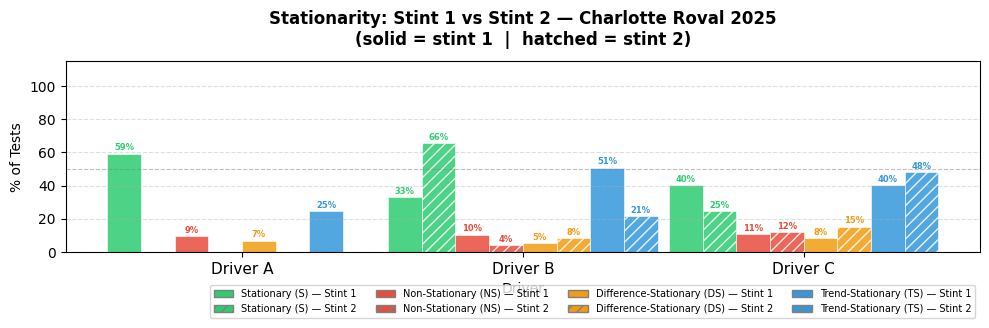

  saved: stationarity_stint_comparison_summit_point.png


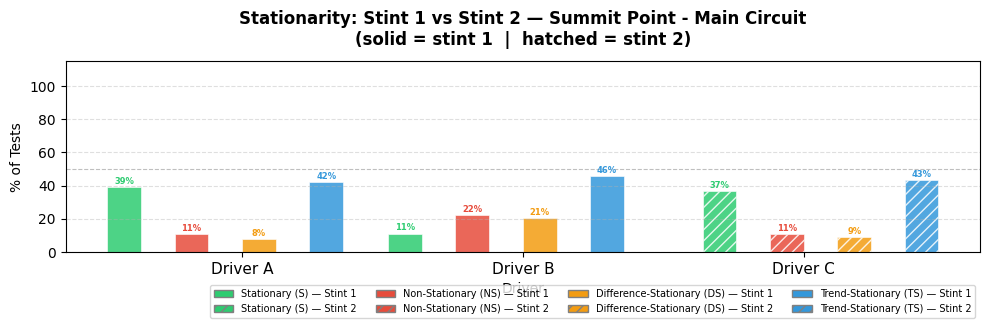

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# ## 11. Stationarity Comparison — Stint 1 vs Stint 2 per Driver × Track
# ══════════════════════════════════════════════════════════════════════════════

import itertools

# ── 11a. Build summary grouped by (Track, Driver, Stint) ─────────────────────
summary_stint_rows = []
for (track_id, driver, stint), grp in df_results.groupby(['Track', 'Driver', 'Stint']):
    valid = grp[grp['Verdict'] != 'N/A']
    if valid.empty:
        continue
    total = len(valid)
    summary_stint_rows.append({
        'Track':               track_id,
        'Driver':              driver,
        'Stint':               stint,
        'Total_Tests':         total,
        'Stationary_%':        round(100 * (valid['Verdict'] == 'Stationary').sum()           / total, 1),
        'Non-Stationary_%':    round(100 * (valid['Verdict'] == 'Non-Stationary').sum()        / total, 1),
        'Diff-Stationary_%':   round(100 * (valid['Verdict'] == 'Difference-Stationary').sum() / total, 1),
        'Trend-Stationary_%':  round(100 * (valid['Verdict'] == 'Trend-Stationary').sum()      / total, 1),
    })

df_summary_stint = pd.DataFrame(summary_stint_rows).sort_values(['Track', 'Driver', 'Stint'])
print(df_summary_stint.to_string(index=False))

# ── 11b. Delta table: Stationary_% change from stint_1 → stint_2 ─────────────
delta_rows = []
for (track_id, driver), grp in df_summary_stint.groupby(['Track', 'Driver']):
    stints = grp.set_index('Stint')
    if 'stint_1' not in stints.index or 'stint_2' not in stints.index:
        continue
    for col in ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']:
        delta = stints.at['stint_2', col] - stints.at['stint_1', col]
        delta_rows.append({'Track': track_id, 'Driver': driver,
                           'Metric': col, 'Stint1': stints.at['stint_1', col],
                           'Stint2': stints.at['stint_2', col], 'Delta': round(delta, 1)})

df_delta = pd.DataFrame(delta_rows)

# ── 11c. Grouped bar chart: stint_1 vs stint_2, one panel per track ──────────
VERDICT_COLS   = ['Stationary_%', 'Non-Stationary_%', 'Diff-Stationary_%', 'Trend-Stationary_%']
VERDICT_COLORS_BAR = {
    'Stationary_%':       '#2ecc71',
    'Non-Stationary_%':   '#e74c3c',
    'Diff-Stationary_%':  '#f39c12',
    'Trend-Stationary_%': '#3498db',
}
VERDICT_LABELS_BAR = {
    'Stationary_%':       'Stationary (S)',
    'Non-Stationary_%':   'Non-Stationary (NS)',
    'Diff-Stationary_%':  'Difference-Stationary (DS)',
    'Trend-Stationary_%': 'Trend-Stationary (TS)',
}
STINT_HATCH = {'stint_1': '', 'stint_2': '///'}   # solid = stint 1, hatched = stint 2

tracks = sorted(df_summary_stint['Track'].unique())

for track_id in tracks:
    sub = df_summary_stint[df_summary_stint['Track'] == track_id]
    drivers = sorted(sub['Driver'].unique())
    stints  = sorted(sub['Stint'].unique())          # e.g. ['stint_1', 'stint_2']
    n_groups = len(drivers)
    n_bars   = len(VERDICT_COLS) * len(stints)       # bars per driver cluster
    bar_w    = 0.12
    offsets  = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 1.5), 3.5))
    x = np.arange(n_groups)

    bar_idx = 0
    legend_handles = []
    for col, color in VERDICT_COLORS_BAR.items():
        for stint in stints:
            values = [
                sub[(sub['Driver'] == d) & (sub['Stint'] == stint)][col].values[0]
                if not sub[(sub['Driver'] == d) & (sub['Stint'] == stint)].empty else 0.0
                for d in drivers
            ]
            hatch = STINT_HATCH.get(stint, '')
            bars  = ax.bar(x + offsets[bar_idx], values, width=bar_w,
                           color=color, hatch=hatch, edgecolor='white',
                           linewidth=0.5, alpha=0.85)
            for bar, val in zip(bars, values):
                if val > 2:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            bar.get_height() + 0.8,
                            f'{val:.0f}%', ha='center', va='bottom',
                            fontsize=6, color=color, fontweight='bold')
            # legend entry only once per (verdict × stint)
            legend_handles.append(
                Patch(facecolor=color, hatch=hatch, edgecolor='gray',
                      label=f"{VERDICT_LABELS_BAR[col]} — {stint.replace('_', ' ').title()}")
            )
            bar_idx += 1

    ax.set_xticks(x)
    ax.set_xticklabels(drivers, fontsize=11)
    ax.set_ylabel('% of Tests', fontsize=10)
    ax.set_xlabel('Driver', fontsize=10)
    ax.set_ylim(0, 115)
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(handles=legend_handles, fontsize=7, loc='upper right',
              bbox_to_anchor=(1.0, -0.15), ncol=4)
    ax.set_title(
        f'Stationarity: Stint 1 vs Stint 2 — {TRACK_CONFIGS[track_id]["track_name"]}\n'
        '(solid = stint 1  |  hatched = stint 2)',
        fontsize=12, fontweight='bold', pad=12)

    _fname = f'stationarity_stint_comparison_{track_id}.{FORMAT}'
    fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
    print(f'  saved: {_fname}')
    plt.tight_layout()
    plt.show()


saved: session_coverage_vs_stationarity.png


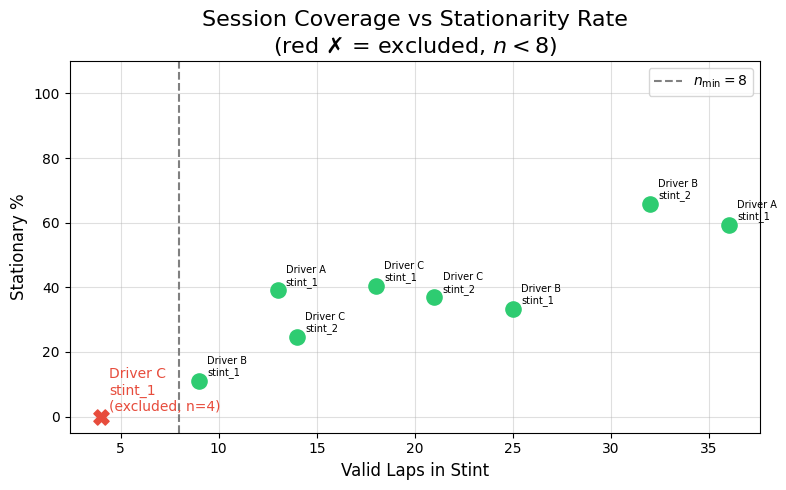

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

# sessões que PASSARAM no threshold (estão em df_summary_stint)
plotted_keys = set()
for _, row in df_summary_stint.iterrows():
    key = (row['Track'], row['Driver'], row['Stint'])
    n = df_results[
        (df_results['Track']  == row['Track']) &
        (df_results['Driver'] == row['Driver']) &
        (df_results['Stint']  == row['Stint'])
    ]['N_Laps'].max()
    ax.scatter(n, row['Stationary_%'], color='#2ecc71', s=120, zorder=3)
    ax.annotate(f"{row['Driver']}\n{row['Stint']}",
                (n, row['Stationary_%']),
                textcoords='offset points', xytext=(6, 4), fontsize=7)
    plotted_keys.add(key)

# sessões EXCLUÍDAS (existem em all_dfs mas não em df_summary_stint)
for (track_id, alias, stint), df in all_dfs.items():
    key = (track_id, alias, stint)
    if key in plotted_keys:
        continue
    n = df['Lap'].nunique()
    ax.scatter(n, 0, color='#e74c3c', s=120, zorder=3, marker='X')
    ax.annotate(f"{alias}\n{stint}\n(excluded, n={n})",
                (n, 0),
                textcoords='offset points', xytext=(6, 4), fontsize=10, color='#e74c3c')

ax.axvline(8, color='gray', linestyle='--', label='$n_{\\min} = 8$')
ax.set_xlabel('Valid Laps in Stint', fontsize=12)
ax.set_ylabel('Stationary %', fontsize=12)
ax.set_title('Session Coverage vs Stationarity Rate\n(red ✗ = excluded, $n < 8$)', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_ylim(-5, 110)

_fname = f'session_coverage_vs_stationarity.{FORMAT}'
fig.savefig(SAVE_DIR / _fname, dpi=DPI, bbox_inches='tight')
print(f'saved: {_fname}')
plt.tight_layout()
plt.show()